In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Mounted at /content/drive


In [ ]:
# Örnek: !unzip "/content/drive/MyDrive/BitirmeProjesi/fer2013.zip" -d "/content/dataset"
!unzip "/content/drive/MyDrive/fer2013.zip" -d "/content/dataset"

Görüntülenen çıkış son 5000 satıra kısaltıldı.
  inflating: /content/dataset/train/sad/Training_65242339.jpg  
  inflating: /content/dataset/train/sad/Training_65267116.jpg  
  inflating: /content/dataset/train/sad/Training_65275626.jpg  
  inflating: /content/dataset/train/sad/Training_6529266.jpg  
  inflating: /content/dataset/train/sad/Training_65329617.jpg  
  inflating: /content/dataset/train/sad/Training_65338712.jpg  
  inflating: /content/dataset/train/sad/Training_65338797.jpg  
  inflating: /content/dataset/train/sad/Training_65387162.jpg  
  inflating: /content/dataset/train/sad/Training_65404494.jpg  
  inflating: /content/dataset/train/sad/Training_65426218.jpg  
  inflating: /content/dataset/train/sad/Training_65430136.jpg  
  inflating: /content/dataset/train/sad/Training_65437377.jpg  
  inflating: /content/dataset/train/sad/Training_6545735.jpg  
  inflating: /content/dataset/train/sad/Training_65463385.jpg  
  inflating: /content/dataset/train/sad/Training_65473985.j

In [ ]:
import tensorflow as tf
import os

# 1. Sabitleri Tanımlayalım (Ayarlarımız)
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
DATA_DIR = "/content/dataset"  # Zipten çıkardığın yer

# Klasör isimlerin 'train' ve 'test' mi yoksa başka bir şey mi?
# Genelde FER-2013 'train' ve 'test' (veya validation) diye çıkar.
# Eğer hata alırsan buradaki isimleri klasörlerine göre düzelt.
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

print("Eğitim verileri yükleniyor...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',       # Etiketleri klasör isimlerinden (angry, happy...) al
    label_mode='int',        # Etiketleri sayıya çevir (0=Angry, 1=Disgust...)
    class_names=None,        # Otomatik bulsun
    color_mode='grayscale',  # Siyah-beyaz
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,            # Veriyi karıştır ki ezberlemesin
    seed=123
)

print("\nTest/Validation verileri yükleniyor...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False            # Test ederken karıştırmaya gerek yok
)

# Sınıf isimlerini görelim (Hangi sayı hangi duygu?)
class_names = train_ds.class_names
print("\nBulunan Duygular (Sınıflar):", class_names)

Eğitim verileri yükleniyor...
Found 28709 files belonging to 7 classes.

Test/Validation verileri yükleniyor...
Found 7178 files belonging to 7 classes.

Bulunan Duygular (Sınıflar): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


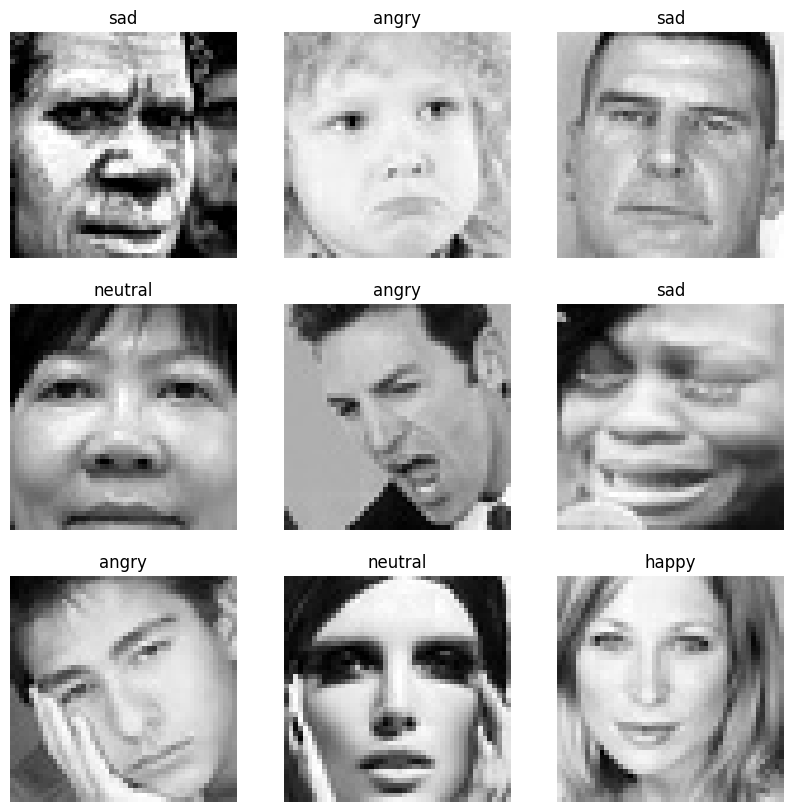

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. train_ds içinden sadece 1 paket (batch) veri al
# take(1) demesek tüm veriyi döngüye sokmaya çalışır, gerek yok.
for images, labels in train_ds.take(1):

    # 2. Bu paketin içindeki ilk 9 resim için bir tablo çizelim
    plt.figure(figsize=(10, 10))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1) # 3x3'lük bir ızgara oluştur

        # --- KRİTİK NOKTA BAŞLIYOR ---

        # 'images[i]' bize TensorFlow Tensor'u olarak gelir.
        # Bunu matematiksel işlem (numpy) yapabileceğimiz formata çeviriyoruz.
        # .astype("uint8") diyerek sayıları 0-255 arasına (tam sayıya) çekiyoruz.
        img = images[i].numpy().astype("uint8")

        # Şu an resmin boyutu: (48, 48, 1) -> Sondaki 1, gri tonlamayı ifade eder.
        # Ama Matplotlib kütüphanesi (48, 48, 1) boyutunu sevmez, hata verir.
        # Ona düz (48, 48) vermemiz lazım.
        # .squeeze() komutu, boyutu 1 olan gereksiz eksenleri sıkar atar.
        img_visual = np.squeeze(img)

        # --- KRİTİK NOKTA BİTTİ ---

        # Resmi gri tonlamada göster
        plt.imshow(img_visual, cmap='gray')

        # Resmin tepesine sayısal etiketin (0, 1, 2...) karşılığı olan ismi yaz
        # labels[i] bize sayıyı verir (örn: 3), class_names[3] ise ismi (örn: 'Happy')
        plt.title(class_names[labels[i]])

        # Çirkin eksen çizgilerini (0, 10, 20...) kapat
        plt.axis("off")

# Çizimi ekrana bas
plt.show()

In [ ]:
# Tensorflow'un otomatik ayarlama özelliğini kullanalım
AUTOTUNE = tf.data.AUTOTUNE

# Eğitim verisi için:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

# Test verisi için (Shuffle yapmaya gerek yok):
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras import layers, models

# Modelin çatısını kuruyoruz (Sequential: Katmanlar arka arkaya dizilecek demek)
model = models.Sequential([

    # --- 1. GİRİŞ VE NORMALİZASYON ---
    # Rescaling: Pikselleri 0-255 arasından 0-1 arasına sıkıştırır.
    # Matematiksel işlemler küçük sayılarla daha hızlı ve kararlı olur.
    layers.Rescaling(1./255, input_shape=(48, 48, 1)),

    # --- 2. GÖRME KATMANLARI (Feature Extraction) ---

    # Katman 1: En basit özellikleri görür (çizgi, köşe)
    # 32 tane filtre kullanır. 3x3 boyutunda mercekler gezdirir.
    # activation='relu': Negatif değerleri (gereksiz bilgiyi) sıfırlar.
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)), # Resmi yarı yarıya küçültür (Özeti alır)

    # Katman 2: Biraz daha karmaşık şekilleri görür (yuvarlak, kavis)
    # Filtre sayısını 64'e çıkardık çünkü detay arttı.
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Katman 3: En karmaşık şekilleri görür (göz, dudak)
    # Filtre sayısı 128 oldu.
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # --- 3. KARAR VERME KATMANLARI (Classification) ---

    # Flatten: 3 boyutlu resim matrisini (kareleri) düz bir çizgi haline getirir.
    # Çünkü karar mekanizması (Dense) düz veri ister.
    layers.Flatten(),

    # Dense (64 nöron): Öğrenilen özellikleri birleştirip yorumlar.
    layers.Dense(64, activation='relu'),

    # Dropout (0.5): Ezberi bozmak için nöronların yarısını rastgele kapatır.
    # Bu, modelin "sadece tek bir yola güvenmesini" engeller. (Sınavda kopya çekmeyi engellemek gibi)
    layers.Dropout(0.5),

    # ÇIKIŞ KATMANI:
    # 7 tane sınıfımız var (Kızgın, Mutlu, Üzgün...). O yüzden 7 nöron.
    # activation='softmax': Çıktıları olasılığa çevirir (Toplamı %100 olacak şekilde).
    # Örn: %80 Mutlu, %10 Şaşkın...
    layers.Dense(7, activation='softmax')
])

# Modeli derleyelim (Compile)
model.compile(optimizer='adam', # Adam: En popüler öğrenme algoritmasıdır. Hatayı en hızlı azaltan yolu bulur.
              loss='sparse_categorical_crossentropy', # Hata hesaplama yöntemi (Sınıflandırma için standarttır)
              metrics=['accuracy']) # Başarıyı neye göre ölçeceğiz? Doğruluk yüzdesi.

# Modelin özetini görelim
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,263 (876.03 KB)

 Trainable params: 224,263 (876.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import layers, models

# Veri çoğaltma bloğunu tanımlıyoruz
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal", input_shape=(48, 48, 1)),
    layers.RandomRotation(0.1), # Yüzde 10'luk bir açıyla sağa veya sola döndür
    layers.RandomZoom(0.1),     # Yüzde 10 oranında yakınlaştır veya uzaklaştır
])

# Modeli baştan kuruyoruz
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Erken durdurma mekanizmasını tanımlıyoruz
early_stopping = EarlyStopping(
    monitor='val_loss',         # Test verisindeki hata oranını (loss) takip et
    patience=5,                 # Eğer hata 5 epoch boyunca iyileşmezse eğitimi durdur
    restore_best_weights=True   # Durdurduğunda, o güne kadarki en düşük hataya sahip ağırlıkları geri yükle
)

# Eğitimi başlatıyoruz (Bu işlem GPU üzerinde birkaç dakika sürecektir)
history = model.fit(
    train_ds,                   # Eğitim verimiz
    validation_data=val_ds,     # Her epoch sonunda kendini test edeceği, daha önce görmediği veri
    epochs=50,                  # Maksimum eğitim döngüsü (EarlyStopping bunu muhtemelen daha erken kesecek)
    callbacks=[early_stopping]  # Güvenlik önlemimizi devreye sokuyoruz
)

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2406 - loss: 1.8213 - val_accuracy: 0.2644 - val_loss: 1.7417
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2915 - loss: 1.7400 - val_accuracy: 0.3536 - val_loss: 1.6208
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3391 - loss: 1.6631 - val_accuracy: 0.4283 - val_loss: 1.5094
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3828 - loss: 1.5809 - val_accuracy: 0.4368 - val_loss: 1.4580
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3989 - loss: 1.5344 - val_accuracy: 0.4642 - val_loss: 1.3964
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4208 - loss: 1.4941 - val_accuracy: 0.4819 - val_loss: 1.3703
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4318 - loss: 1.4680 - val_accuracy: 0.4841 - val_loss: 1.3462
Epoch 8/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4460 - loss: 1.4410 - val_accuracy:

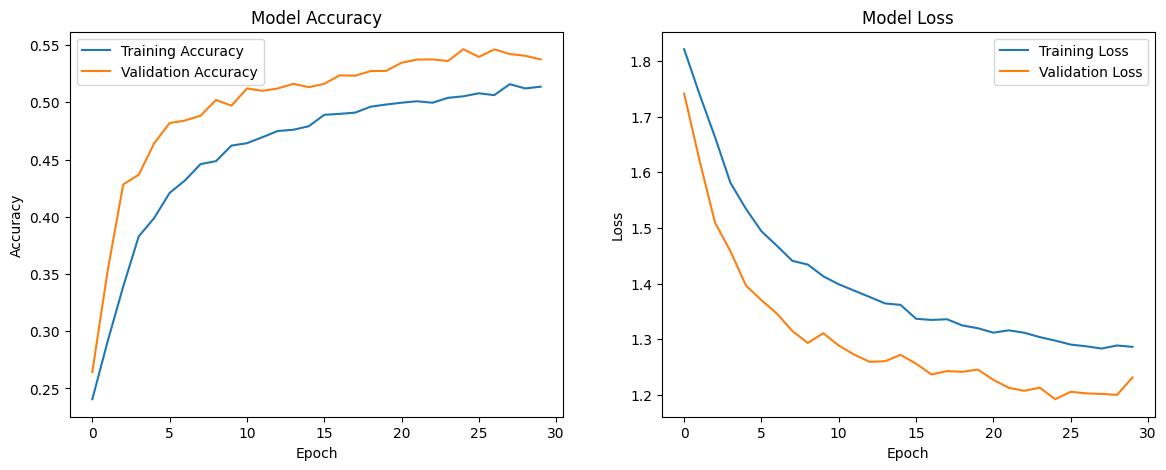

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

Model test verisi üzerinde tahminler yapıyor, lütfen bekleyin...
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


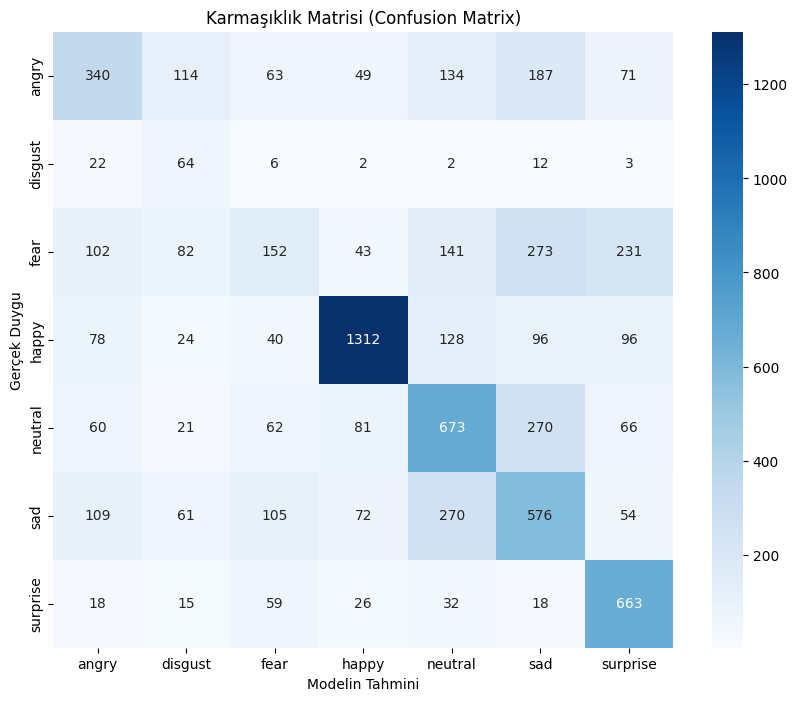

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("Model test verisi üzerinde tahminler yapıyor, lütfen bekleyin...")

# 1. Test verisindeki GERÇEK etiketleri (cevap anahtarını) topluyoruz
# val_ds'yi oluştururken shuffle=False dediğimiz için sırası hiç bozulmayacak
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# 2. Modelden test verisi için TAHMİNLERİ alıyoruz
# Model bize % oranlar verecek (örn: [0.1, 0.8, 0.05...])
y_pred_probs = model.predict(val_ds)

# 3. En yüksek oranlı tahmini seçiyoruz (örn: %80 olan 1. indeksi seç)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Karmaşıklık Matrisini (Confusion Matrix) hesaplıyoruz
cm = confusion_matrix(y_true, y_pred)

# 5. Görselleştirme (Isı Haritası - Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Duygu')
plt.xlabel('Modelin Tahmini')
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Eğitim verisindeki gerçek cevap anahtarını alıyoruz
train_labels = np.concatenate([y for x, y in train_ds], axis=0)

# Scikit-learn bizim için ağırlıkları 'balanced' (dengeli) şekilde hesaplıyor
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Keras'ın anlayacağı formata (sözlük formatına) çeviriyoruz
class_weight_dict = dict(enumerate(class_weights))

print("Hesaplanan Sınıf Ağırlıkları:")
for sinif_no, agirlik in class_weight_dict.items():
    print(f"{class_names[sinif_no]}: {agirlik:.2f}")

Hesaplanan Sınıf Ağırlıkları:
angry: 1.03
disgust: 9.41
fear: 1.00
happy: 0.57
neutral: 0.83
sad: 0.85
surprise: 1.29


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Güvenlik önlemimizi (Early Stopping) tekrar tanımlıyoruz
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Ağırlıklandırılmış (Weighted) eğitim başlıyor...")

# Eğitimi başlatıyoruz
history_weighted = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stopping],
    class_weight=class_weight_dict  # İŞTE YENİ SİLAHIMIZ BURASI!
)

Ağırlıklandırılmış (Weighted) eğitim başlıyor...
Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4679 - loss: 1.5053 - val_accuracy: 0.5093 - val_loss: 1.2993
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4629 - loss: 1.4670 - val_accuracy: 0.5018 - val_loss: 1.3218
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4720 - loss: 1.4310 - val_accuracy: 0.5014 - val_loss: 1.3119
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4695 - loss: 1.4362 - val_accuracy: 0.4820 - val_loss: 1.3731
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4710 - loss: 1.4236 - val_accuracy: 0.5266 - val_loss: 1.2561
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4643 - loss: 1.4175 - val_accuracy: 0.4990 - val_loss: 1.3205
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4713 - loss: 1.4119 - val_accuracy: 0.5217 - val_loss: 1.2632
Epoch 8/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step

In [ ]:
from sklearn.metrics import classification_report

print("Detaylı Performans Raporu:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Detaylı Performans Raporu:

              precision    recall  f1-score   support

       angry       0.47      0.35      0.40       958
     disgust       0.17      0.58      0.26       111
        fear       0.31      0.15      0.20      1024
       happy       0.83      0.74      0.78      1774
     neutral       0.49      0.55      0.52      1233
         sad       0.40      0.46      0.43      1247
    surprise       0.56      0.80      0.66       831

    accuracy                           0.53      7178
   macro avg       0.46      0.52      0.46      7178
weighted avg       0.53      0.53      0.52      7178



In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(7, activation='softmax')
])

dusuk_hizli_adam = Adam(learning_rate=0.002)

model.compile(optimizer=dusuk_hizli_adam,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

print("Yeni hiperparametrelerle eğitim başlıyor...")

history_tuned = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stopping],
    class_weight=class_weight_dict
)

Yeni hiperparametrelerle eğitim başlıyor...
Epoch 1/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.1606 - loss: 1.9409 - val_accuracy: 0.1879 - val_loss: 1.9137
Epoch 2/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1699 - loss: 1.9185 - val_accuracy: 0.2136 - val_loss: 1.8838
Epoch 3/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1994 - loss: 1.8858 - val_accuracy: 0.2373 - val_loss: 1.8046
Epoch 4/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1966 - loss: 1.8609 - val_accuracy: 0.2439 - val_loss: 1.8097
Epoch 5/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1961 - loss: 1.8506 - val_accuracy: 0.2260 - val_loss: 1.8254
Epoch 6/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2082 - loss: 1.8340 - val_accuracy: 0.2173 - val_loss: 1.8215
Epoch 7/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2357 - loss: 1.8177 - val_accuracy: 0.3182 - val_loss: 1.7404
Epoch 8/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/s

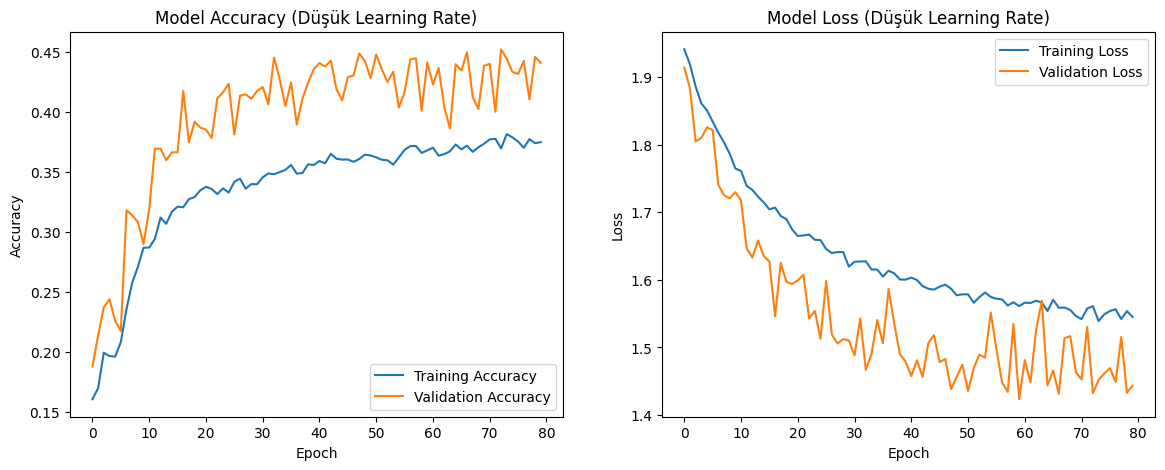

In [ ]:
import matplotlib.pyplot as plt

# Yeni eğittiğimiz 'history_tuned' değişkenini kullanıyoruz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Başarı (Accuracy) Grafiği
ax1.plot(history_tuned.history['accuracy'], label='Training Accuracy')
ax1.plot(history_tuned.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy (Düşük Learning Rate)')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Hata (Loss) Grafiği
ax2.plot(history_tuned.history['loss'], label='Training Loss')
ax2.plot(history_tuned.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss (Düşük Learning Rate)')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

Model test verisi üzerinde tahminler yapıyor, lütfen bekleyin...
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


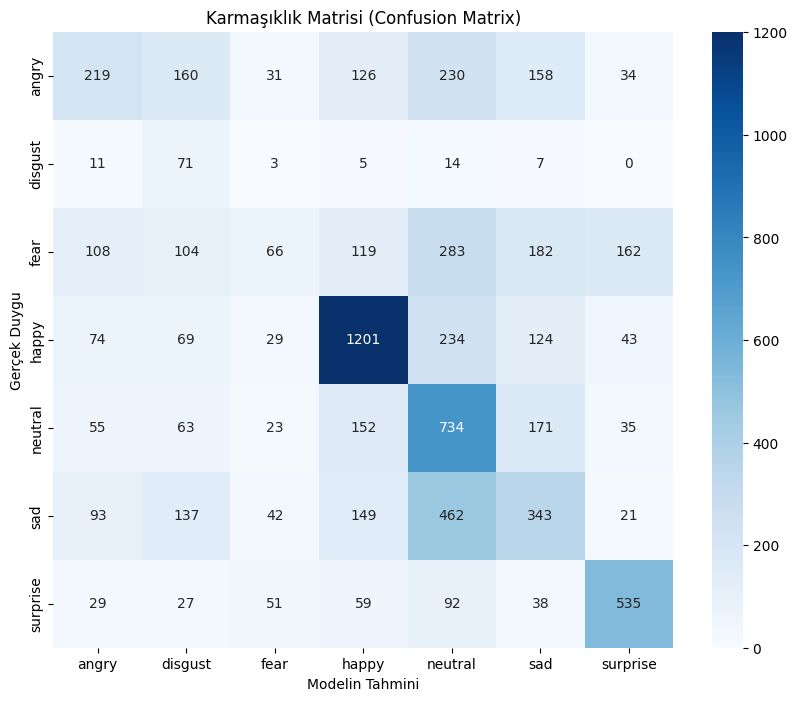

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("Model test verisi üzerinde tahminler yapıyor, lütfen bekleyin...")

# 1. Test verisindeki GERÇEK etiketleri (cevap anahtarını) topluyoruz
# val_ds'yi oluştururken shuffle=False dediğimiz için sırası hiç bozulmayacak
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# 2. Modelden test verisi için TAHMİNLERİ alıyoruz
# Model bize % oranlar verecek (örn: [0.1, 0.8, 0.05...])
y_pred_probs = model.predict(val_ds)

# 3. En yüksek oranlı tahmini seçiyoruz (örn: %80 olan 1. indeksi seç)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Karmaşıklık Matrisini (Confusion Matrix) hesaplıyoruz
cm = confusion_matrix(y_true, y_pred)

# 5. Görselleştirme (Isı Haritası - Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Duygu')
plt.xlabel('Modelin Tahmini')
plt.show()

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. Veri Çoğaltma (Augmentation) Katmanı
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal", input_shape=(48, 48, 1)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 2. Ana Model Mimarisi
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(7, activation='softmax')
])

# 3. Derleme (Standart 0.001 learning rate kullanıyoruz)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Erken Durdurma (Sabrı 10 olarak ayarladık)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("Nihai model eğitimi başlıyor...")

# 5. Eğitimi Başlatma (Sınıf ağırlıkları dahil)
history_final = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stopping],
    class_weight=class_weight_dict
)

Nihai model eğitimi başlıyor...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1446 - loss: 1.9469 - val_accuracy: 0.1684 - val_loss: 1.9412
Epoch 2/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1789 - loss: 1.9237 - val_accuracy: 0.2191 - val_loss: 1.8638
Epoch 3/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2254 - loss: 1.8530 - val_accuracy: 0.2257 - val_loss: 1.8491
Epoch 4/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2375 - loss: 1.8315 - val_accuracy: 0.2697 - val_loss: 1.7919
Epoch 5/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2584 - loss: 1.8031 - val_accuracy: 0.2880 - val_loss: 1.7633
Epoch 6/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2789 - loss: 1.7754 - val_accuracy: 0.3557 - val_loss: 1.6809
Epoch 7/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3126 - loss: 1.7385 - val_accuracy: 0.3429 - val_loss: 1.6739
Epoch 8/100
449/449 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3273 - loss: 1.7042 - val_accuracy

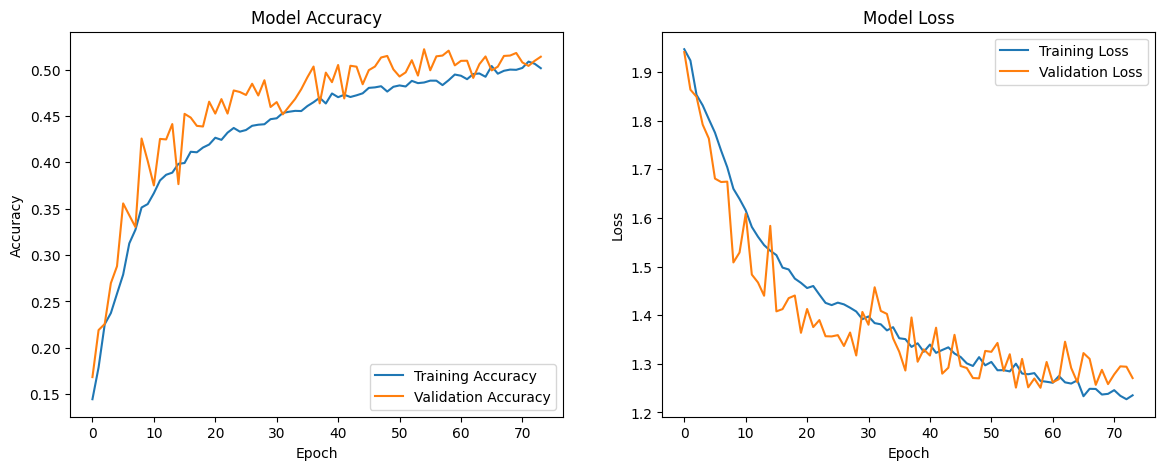

In [ ]:
import matplotlib.pyplot as plt

# Yeni eğittiğimiz 'history_tuned' değişkenini kullanıyoruz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Başarı (Accuracy) Grafiği
ax1.plot(history_final.history['accuracy'], label='Training Accuracy')
ax1.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Hata (Loss) Grafiği
ax2.plot(history_final.history['loss'], label='Training Loss')
ax2.plot(history_final.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

Model test verisi üzerinde tahminler yapıyor, lütfen bekleyin...
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


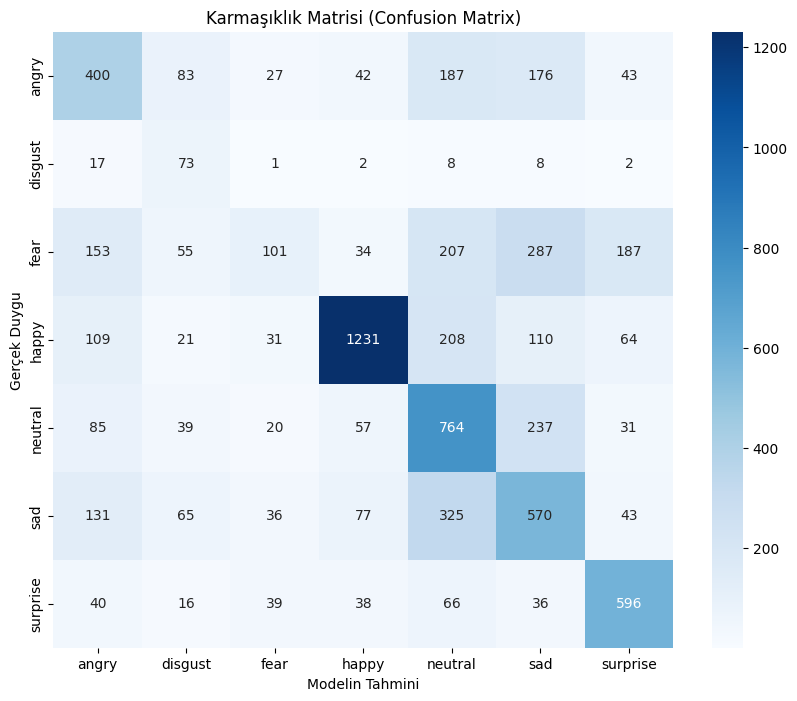

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("Model test verisi üzerinde tahminler yapıyor, lütfen bekleyin...")

# 1. Test verisindeki GERÇEK etiketleri (cevap anahtarını) topluyoruz
# val_ds'yi oluştururken shuffle=False dediğimiz için sırası hiç bozulmayacak
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# 2. Modelden test verisi için TAHMİNLERİ alıyoruz
# Model bize % oranlar verecek (örn: [0.1, 0.8, 0.05...])
y_pred_probs = model.predict(val_ds)

# 3. En yüksek oranlı tahmini seçiyoruz (örn: %80 olan 1. indeksi seç)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Karmaşıklık Matrisini (Confusion Matrix) hesaplıyoruz
cm = confusion_matrix(y_true, y_pred)

# 5. Görselleştirme (Isı Haritası - Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Duygu')
plt.xlabel('Modelin Tahmini')
plt.show()

In [ ]:
model.save('emotion_model.keras')